In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [4]:
def log_geologique_designe(ax, layers, x0, width, depth_max, title="", title_color="black"):

    ax.add_patch(Rectangle((x0, 0), width, depth_max, fill=False, ec="black", lw=1.2))

    for L in layers:
        top, bottom = L['top'], L['bottom']
        label = L['label']

        ax.add_patch(Rectangle(
            (x0, top),
            width,
            bottom - top,
            lw=1.0,
            ec="black",
            fc=("white" if L.get("fill") is None else L['fill']),
            hatch=L.get("hatch", None)
        ))

        layer_height = bottom - top
        fontsize = max(6, min(9, layer_height * 0.7))

        if L.get("fill") == "black":
            bbox_style = None
            text_color = "white"
        else:
            bbox_style = dict(facecolor="white", edgecolor="none",
                              boxstyle="round,pad=0.15", alpha=1)
            text_color = L.get("label_color", "black")


        ax.text(x0 + width / 2, (top + bottom) / 2,
                label,
                ha="center", va="center",
                fontsize=fontsize,
                color=text_color,
                family="DejaVu Sans",
                bbox=bbox_style,
                zorder=5)


    ax.text(x0 + width / 2, -0.02 * depth_max, title,
            ha="center", va="top", fontsize=9, fontweight="bold", color=title_color)


def plot_two_logs(layers_left, layers_right,
                  title_left="Log 1", title_right="Log 2",
                  tick_every=5, depth_max=None,
                  figsize=(6, 8), save_png=None, save_pdf=None):
    
    if depth_max is None:
        depth_max = max(
            max(L['bottom'] for L in layers_left),
            max(L['bottom'] for L in layers_right)
        )

    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    ax.set_xlim(0, 1.6)
    ax.set_ylim(depth_max, 0)
    ax.spines[['right', 'top', 'bottom']].set_visible(False)
    ax.set_ylabel("Profondeur (m)", fontsize=9)

    ax.tick_params(axis='x', length=0, labelbottom=False)


    ax.set_yticks(range(0, int(depth_max) + 1, tick_every))
    ax.tick_params(axis='y', direction='out', length=3, width=1, labelsize=8)


    col_w = 0.6
    log_geologique_designe(ax, layers_left,  0.15, col_w, depth_max, title_left, title_color="red")
    log_geologique_designe(ax, layers_right, 0.85, col_w, depth_max, title_right, title_color="black")

    plt.tight_layout()
    if save_png:
        plt.savefig(save_png, dpi=600, bbox_inches="tight")
    if save_pdf:
        plt.savefig(save_pdf, bbox_inches="tight")
    return fig, ax

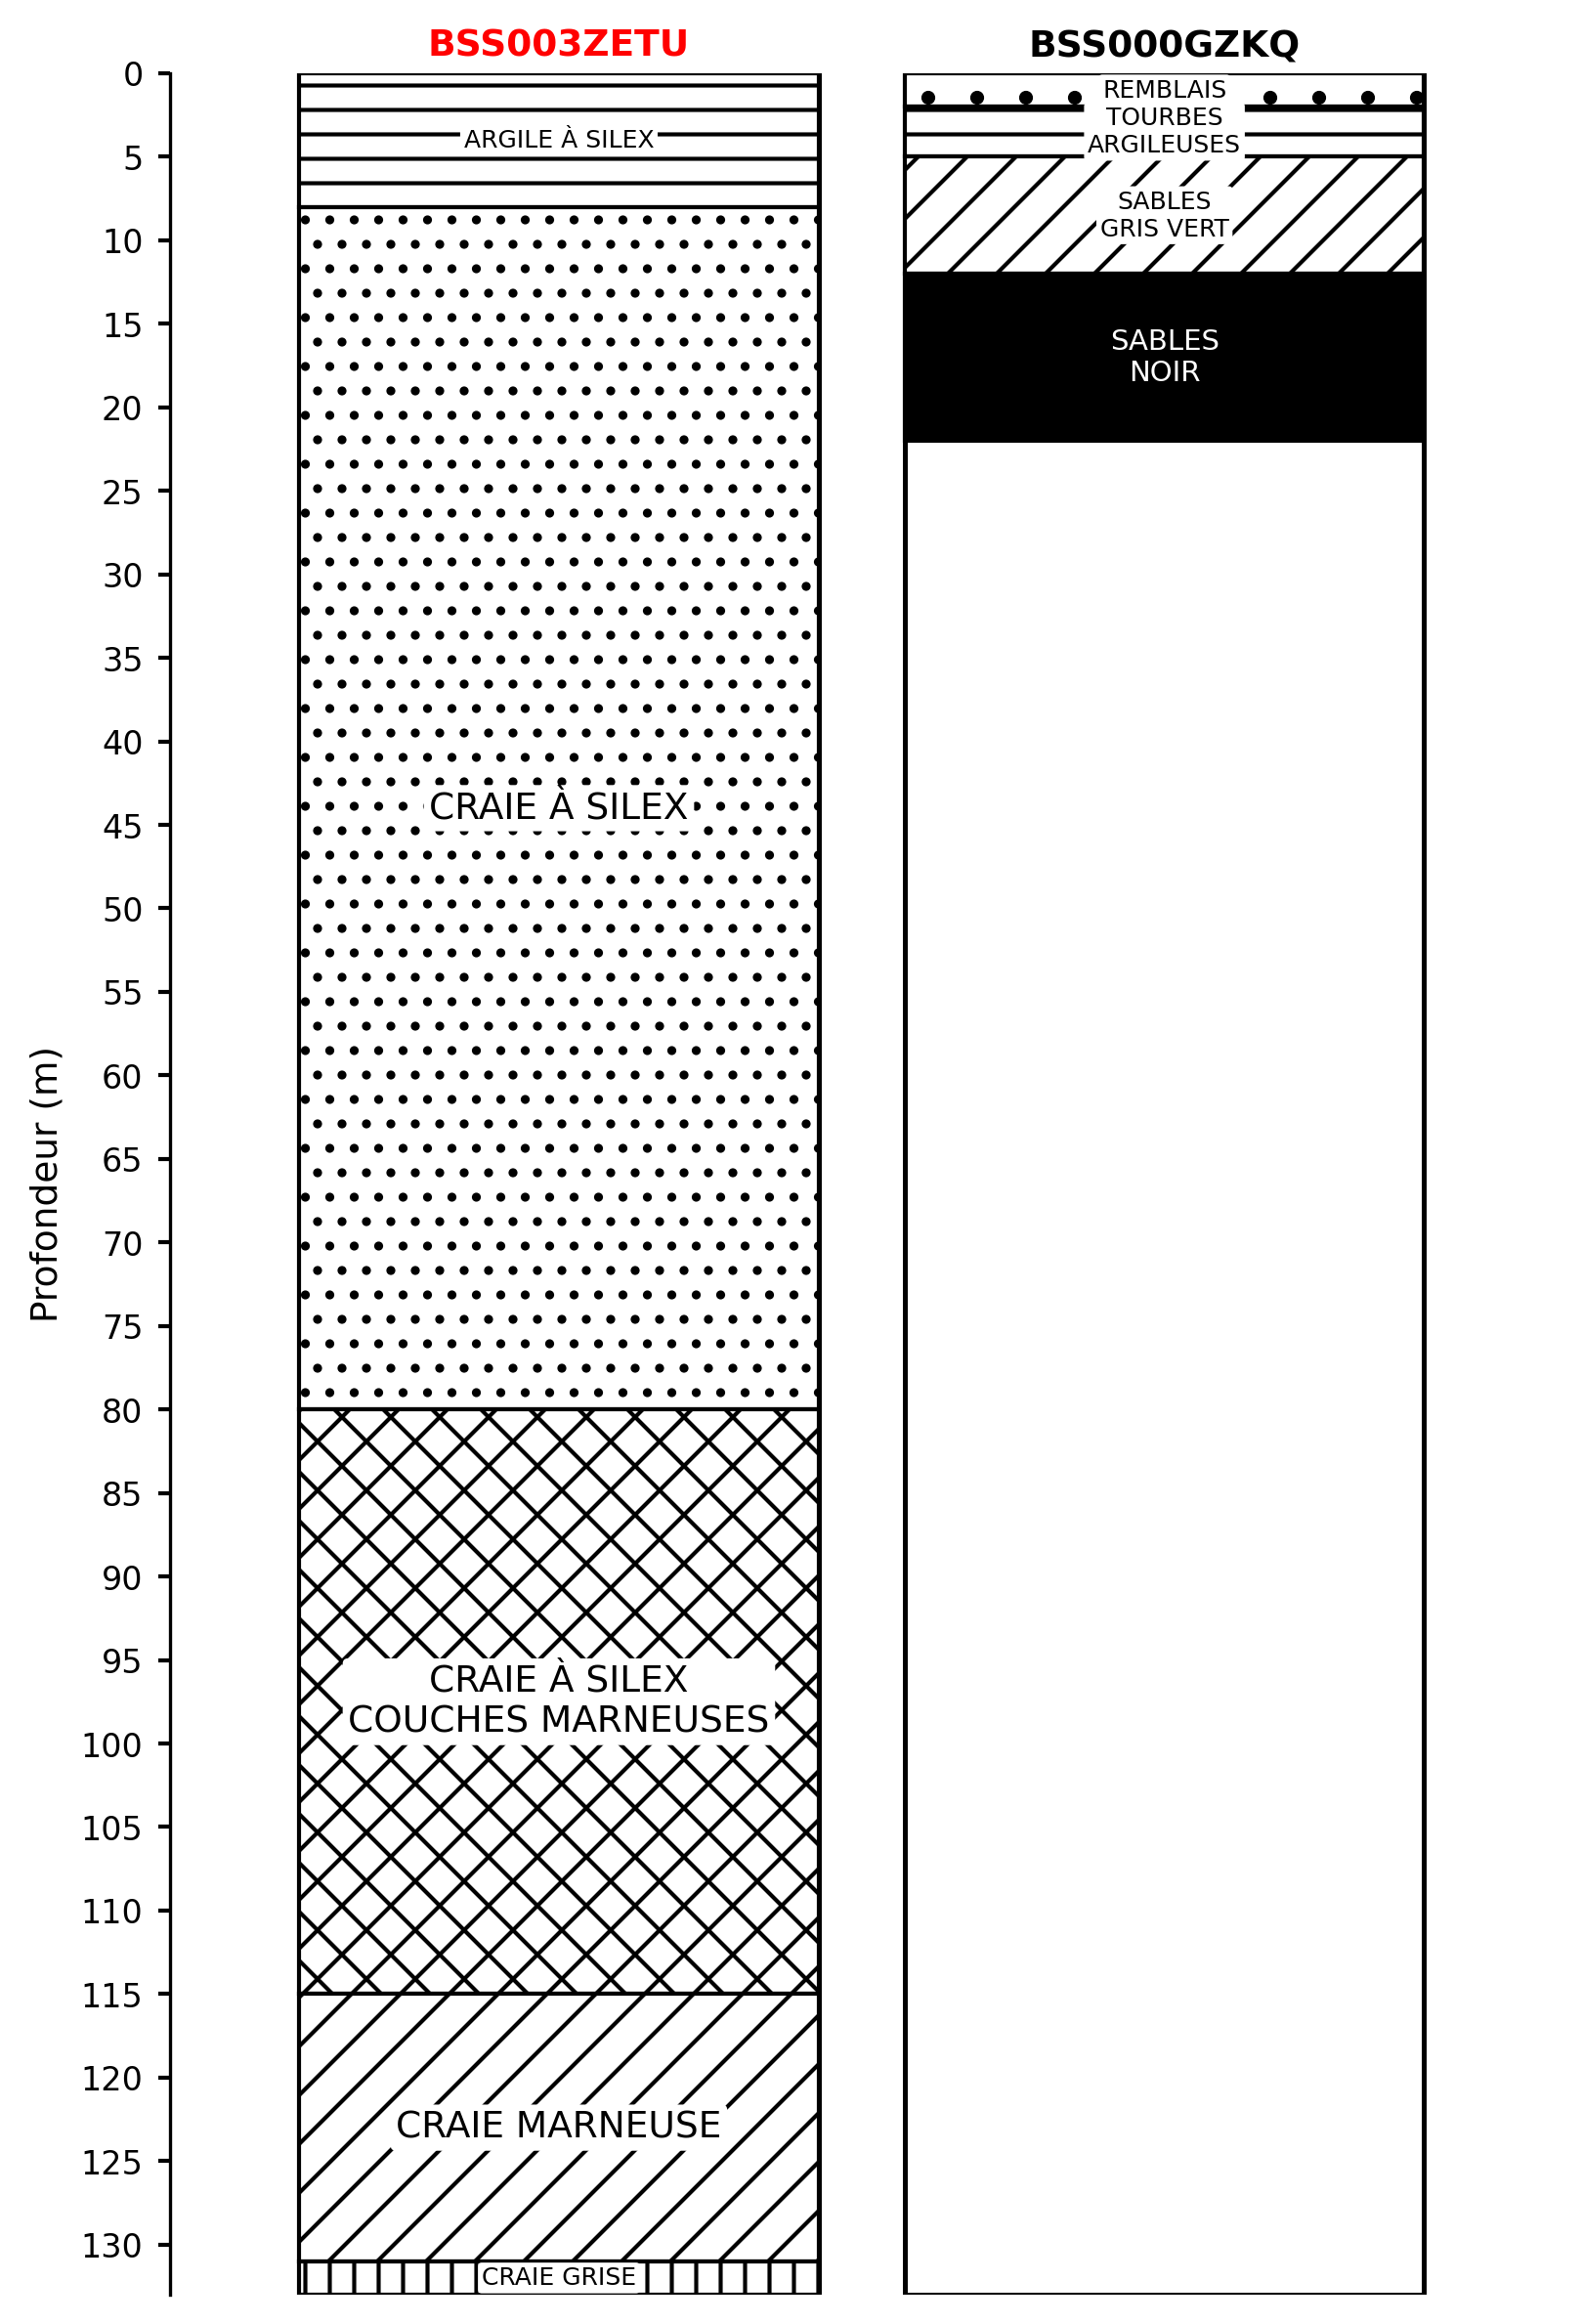

In [5]:
layers_A = [
    {"top": 0,   "bottom": 8,   "label": "ARGILE À SILEX",                       "hatch": "--"},
    {"top": 8,   "bottom": 80,  "label": "CRAIE À SILEX",                        "hatch": ".."},
    {"top": 80,  "bottom": 115, "label": "CRAIE À SILEX\nCOUCHES MARNEUSES",     "hatch": "xx"},
    {"top": 115, "bottom": 131, "label": "CRAIE MARNEUSE",                       "hatch": "//"},
    {"top": 131, "bottom": 133, "label": "CRAIE GRISE",                          "hatch": "||"},]

layers_B = [
    {"top": 0,  "bottom": 2,   "label": "REMBLAIS",            "hatch": ".",  "fill": None},
    {"top": 2,  "bottom": 5,   "label": "TOURBES\nARGILEUSES", "hatch": "--"},
    {"top": 5,  "bottom": 12,  "label": "SABLES\nGRIS VERT",   "hatch": "//"},
    {"top": 12, "bottom": 22,  "label": "SABLES\nNOIR",        "fill": "black"},]

if __name__ == "__main__":
    plot_two_logs(
        layers_left=layers_A,
        layers_right=layers_B,
        title_left="BSS003ZETU",
        title_right="BSS000GZKQ",
        tick_every=5,
        depth_max=133,
        figsize=(5.5, 8),
        save_png="double_log_final.png",
    )
    plt.show()